In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings as war
war.filterwarnings('ignore')

In [2]:
df = pd.read_csv('https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/293/original/walmart_data.csv?1641285094')
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


In [3]:
df.shape

(550068, 10)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   User_ID                     550068 non-null  int64 
 1   Product_ID                  550068 non-null  object
 2   Gender                      550068 non-null  object
 3   Age                         550068 non-null  object
 4   Occupation                  550068 non-null  int64 
 5   City_Category               550068 non-null  object
 6   Stay_In_Current_City_Years  550068 non-null  object
 7   Marital_Status              550068 non-null  int64 
 8   Product_Category            550068 non-null  int64 
 9   Purchase                    550068 non-null  int64 
dtypes: int64(5), object(5)
memory usage: 42.0+ MB


In [5]:
df.columns

Index(['User_ID', 'Product_ID', 'Gender', 'Age', 'Occupation', 'City_Category',
       'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category',
       'Purchase'],
      dtype='object')

In [6]:
df.describe()

,User_ID,Occupation,Marital_Status,Product_Category,Purchase
count,5.500680e+05,550068.000000,550068.000000,550068.000000,550068.000000
mean,1.003029e+06,8.076707,0.409653,5.404270,9263.968713
std,1.727592e+03,6.522660,0.491770,3.936211,5023.065394
min,1.000001e+06,0.000000,0.000000,1.000000,12.000000
25%,1.001516e+06,2.000000,0.000000,1.000000,5823.000000
50%,1.003077e+06,7.000000,0.000000,5.000000,8047.000000
75%,1.004478e+06,14.000000,1.000000,8.000000,12054.000000
max,1.006040e+06,20.000000,1.000000,20.000000,23961.000000


In [7]:
def outlier_detect(df,colname,nrows=2,mcols=2,width=20,height=15):
    fig , ax = plt.subplots(nrows,mcols,figsize=(width,height))
    fig.set_facecolor("lightgrey")
    rows = 0
    for var in colname:        
        ax[rows][0].set_title("Boxplot for Outlier Detection ", fontweight="bold")
        plt.ylabel(var, fontsize=12)
        sns.boxplot(y = df[var],color='g',ax=ax[rows][0])
        
        sns.distplot(df[var],color='g',ax=ax[rows][1])
        ax[rows][1].axvline(df[var].mean(), color='r', linestyle='--', label="Mean")
        ax[rows][1].axvline(df[var].median(), color='g', linestyle='-', label="Median")
        ax[rows][1].axvline(df[var].mode()[0], color='royalblue', linestyle='-', label="Mode")
        ax[rows][1].set_title("Outlier Detection ", fontweight="bold")
        ax[rows][1].legend({'Mean':df[var].mean(),'Median':df[var].median(),'Mode':df[var].mode()})
        rows += 1

    plt.show()

In [8]:
df=df.drop_duplicates()
df.shape

(550068, 10)

In [9]:
df.nunique()

User_ID                        5891
Product_ID                     3631
Gender                            2
Age                               7
Occupation                       21
City_Category                     3
Stay_In_Current_City_Years        5
Marital_Status                    2
Product_Category                 20
Purchase                      18105
dtype: int64

In [10]:
df.loc[:,'Product_ID'].value_counts()

Product_ID
P00265242    1880
P00025442    1615
P00110742    1612
P00112142    1562
P00057642    1470
             ... 
P00325342       1
P00312542       1
P00008942       1
P00315142       1
P00365942       1
Name: count, Length: 3631, dtype: int64

In [11]:
df['Product_ID'].unique()

array(['P00069042', 'P00248942', 'P00087842', ..., 'P00370293',
       'P00371644', 'P00370853'], shape=(3631,), dtype=object)

In [12]:
df['Gender'].unique()

array(['F', 'M'], dtype=object)

In [13]:
df['Age'].unique()

array(['0-17', '55+', '26-35', '46-50', '51-55', '36-45', '18-25'],
      dtype=object)

In [14]:
df['City_Category'].unique()

array(['A', 'C', 'B'], dtype=object)

In [15]:
df['Stay_In_Current_City_Years'].unique()

array(['2', '4+', '3', '1', '0'], dtype=object)

In [16]:
df['Marital_Status'].unique()

array([0, 1])

In [17]:
df['Product_Category'].unique()

array([ 3,  1, 12,  8,  5,  4,  2,  6, 14, 11, 13, 15,  7, 16, 18, 10, 17,
        9, 20, 19])

In [18]:
df.head(5)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


In [19]:
def age_mapping(df):
    
    if df == '0-17':
        return 'Teenager'
    elif df == '18-25':
        return 'Early 20s'
    elif df == '26-35':
        return 'Early 30s'
    elif df == '36-45':
        return 'Middle Age'
    elif df == '46-50':
        return 'Middle Age'
    elif df == '51-55':
        return 'Senior'
    else:
        return 'Senior'

df['Age_label'] = df['Age'].apply(age_mapping)

In [20]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase,Age_label
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370,Teenager
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200,Teenager
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422,Teenager
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057,Teenager
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969,Senior


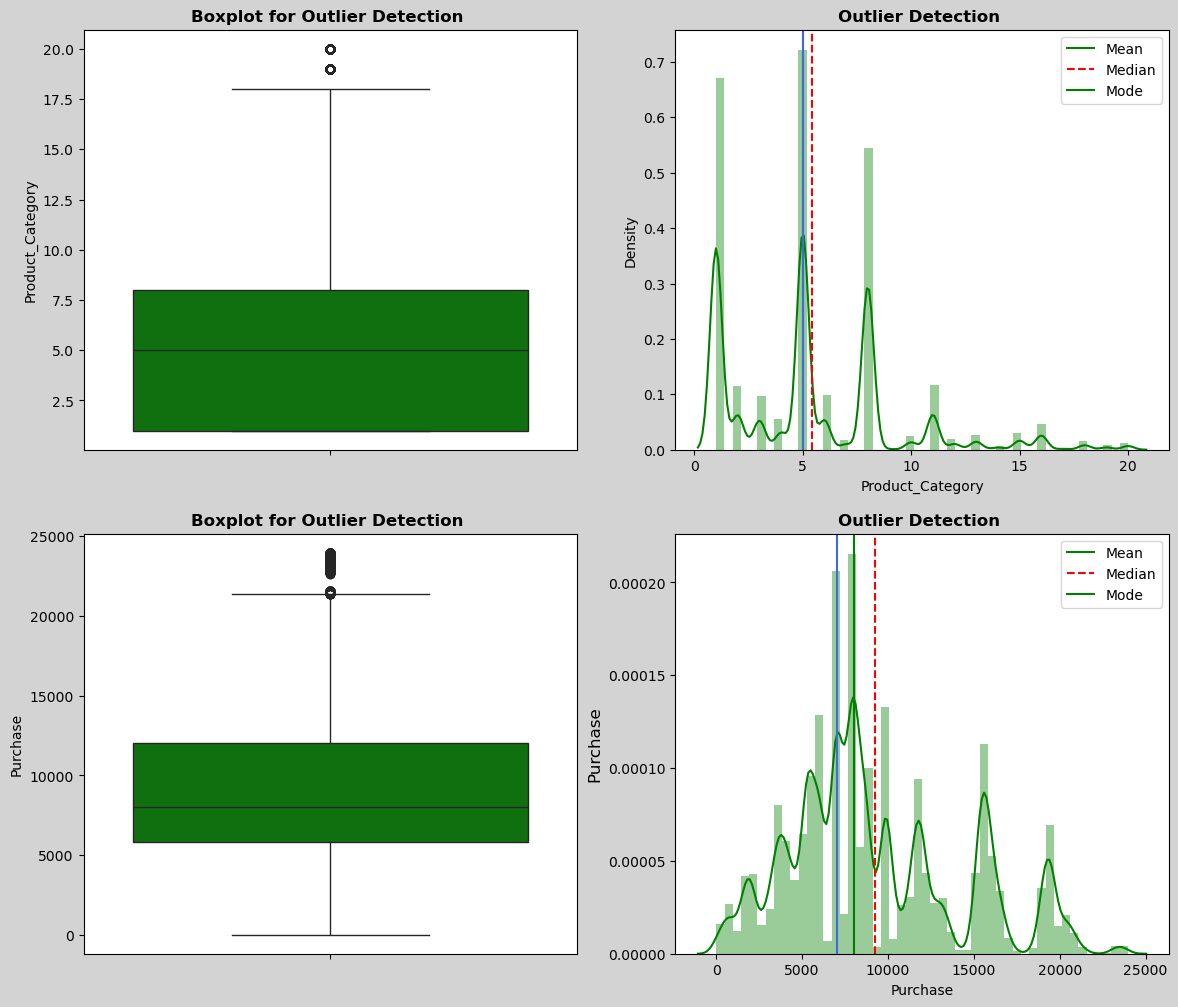

In [21]:
col_num = ['Product_Category','Purchase']
outlier_detect(df,col_num,2,2,14,12)

In [22]:
df_v1 = df.copy()

In [23]:
#Outlier Treatment: Remove top 5% & bottom 1% of the Column Outlier values
Q3 = df_v1['Purchase'].quantile(0.75)
Q1 = df_v1['Purchase'].quantile(0.25)
IQR = Q3-Q1
df_v1 = df_v1[(df_v1['Purchase'] > Q1 - 1.5*IQR) & (df_v1['Purchase'] < Q3 + 1.5*IQR)]
plt.show()

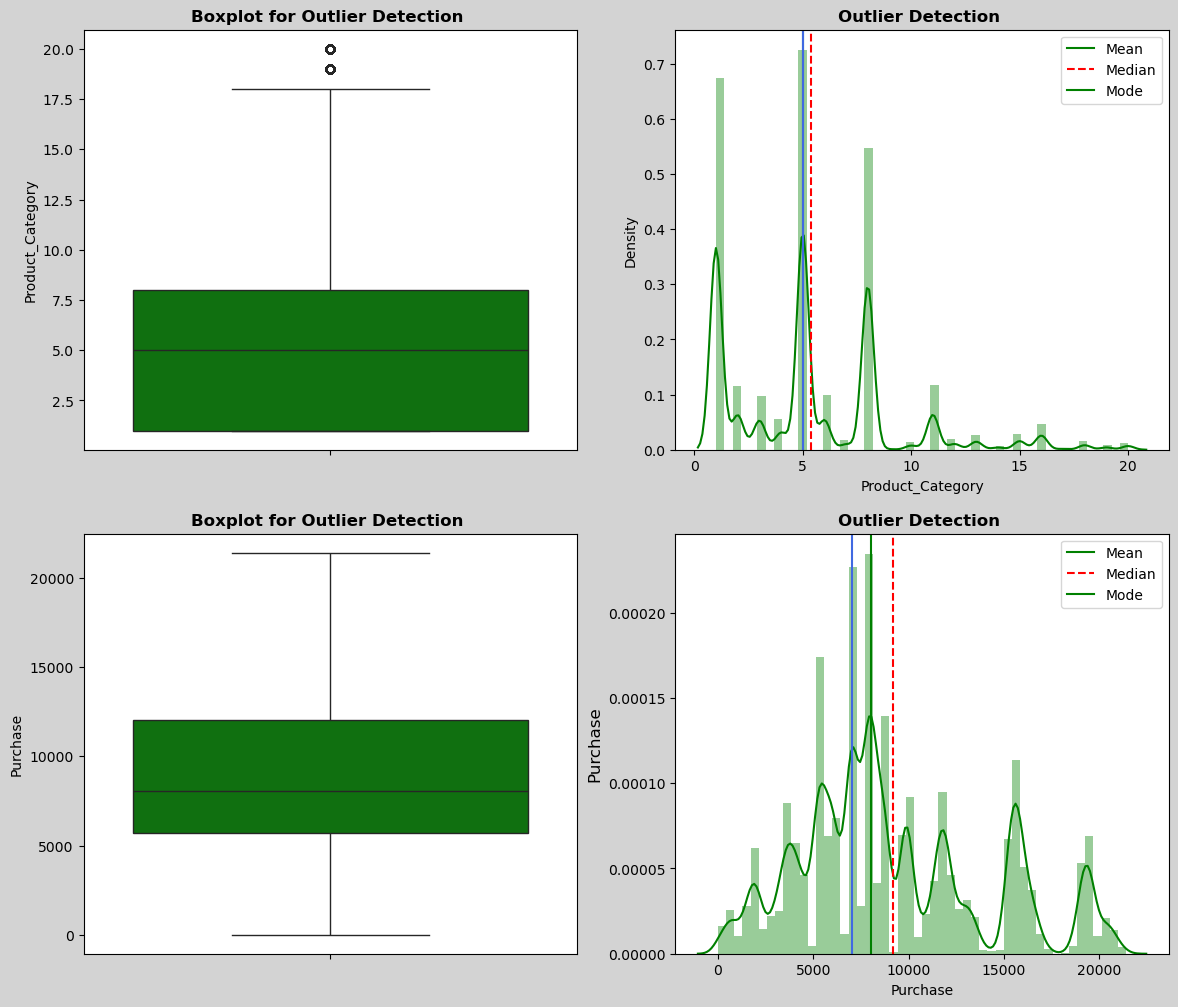

In [24]:

col_num = ['Product_Category','Purchase']
outlier_detect(df_v1,col_num,2,2,14,12)

In [25]:
df_v1.shape

(547391, 11)

In [26]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase,Age_label
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370,Teenager
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200,Teenager
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422,Teenager
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057,Teenager
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969,Senior


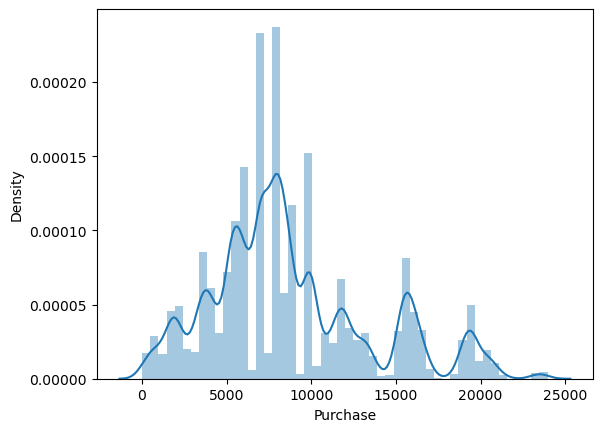

In [27]:
sns.distplot(df[df['Gender'] == 'F']['Purchase'],hist=True )
plt.show()

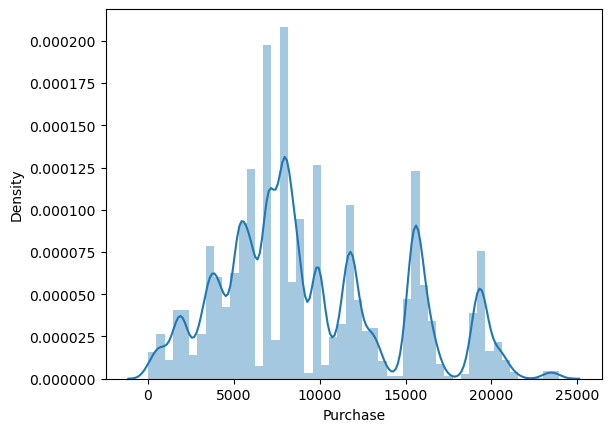

In [28]:
sns.distplot(df[df['Gender'] == 'M']['Purchase'],hist=True )
plt.show()

In [29]:
print('Population Mean of for Male Purchase: ',df[df['Gender'] == 'M']['Purchase'].mean())
print('Population Mean of for Female Purchase: ',df[df['Gender'] == 'F']['Purchase'].mean())

Population Mean of for Male Purchase:  9437.526040472265
Population Mean of for Female Purchase:  8734.565765155476


In [30]:
male_sample_means=[df[df['Gender']=='M']['Purchase'].sample(300).mean() for i in range(1000)]

In [31]:
female_sample_means=[df[df['Gender']=='F']['Purchase'].sample(300).mean() for i in range(1000)]

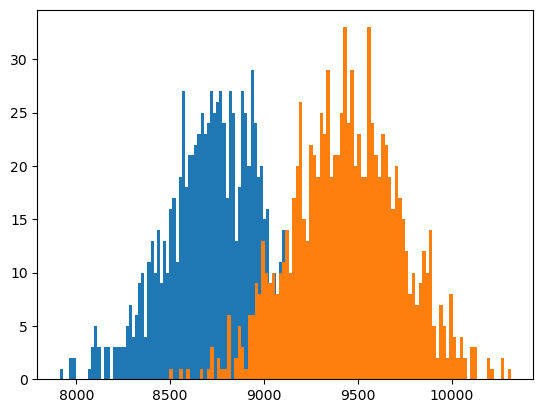

In [45]:
plt.hist(female_sample_means, bins=100)
plt.hist(male_sample_means, bins= 100)
plt.show()

In [46]:
#Confidence intervals for males and females

In [33]:
np.mean(male_sample_means), np.std(male_sample_means)

(np.float64(9440.439956666667), np.float64(288.48794011471506))

In [34]:
np.mean(female_sample_means), np.std(female_sample_means)

(np.float64(8760.62003), np.float64(275.3517421337241))

In [35]:
#Z score if the confidence interval is 95% and it is a one sided tale test

In [36]:
Lower_limit_males = np.mean(male_sample_means)- (np.std(male_sample_means)/np.sqrt(1000))
Upper_limit_males = np.mean(male_sample_means)+ (np.std(male_sample_means)/np.sqrt(1000))

print(Lower_limit_males, Upper_limit_males)

9431.31716698414 9449.562746349195


In [37]:
Lower_limit_females = np.mean(female_sample_means)- (np.std(female_sample_means)/np.sqrt(1000))
Upper_limit_females = np.mean(female_sample_means)+ (np.std(female_sample_means)/np.sqrt(1000))

print(Lower_limit_females, Upper_limit_females)

8751.912643371621 8769.327416628379


In [38]:
#With 95% confidence we are able to find the confidence interval of purchases done by both male and female

In [39]:
Lower_limit_males= np.mean(male_sample_means)- (np.std(male_sample_means))*1.96
Upper_limit_males= np.mean(male_sample_means)+ (np.std(male_sample_means))*1.96

(Lower_limit_males, Upper_limit_males)

(np.float64(8875.003594041826), np.float64(10005.876319291508))

In [40]:
Lower_limit_females= np.mean(female_sample_means)- (np.std(female_sample_means))*1.96
Upper_limit_females= np.mean(female_sample_means)+ (np.std(female_sample_means))*1.96

(Lower_limit_females, Upper_limit_females)

(np.float64(8220.930615417901), np.float64(9300.309444582099))

In [41]:
# Get the corresponding values of 2.5th and 97.5th percentiles
conf_interval = np.percentile(male_sample_means,[2.5,97.5])
# Print the interval
print("The confidence interval: ",conf_interval)

The confidence interval:  [ 8883.40908333 10000.31233333]


In [42]:
# Get the corresponding values of 2.5th and 97.5th percentiles
conf_interval = np.percentile(female_sample_means,[2.5,97.5])
# Print the interval
print("The confidence interval: ",conf_interval)

The confidence interval:  [8210.88733333 9278.59575   ]


In [ ]:
#Analysis for Married vs Unmarried

In [47]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase,Age_label
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370,Teenager
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200,Teenager
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422,Teenager
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057,Teenager
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969,Senior


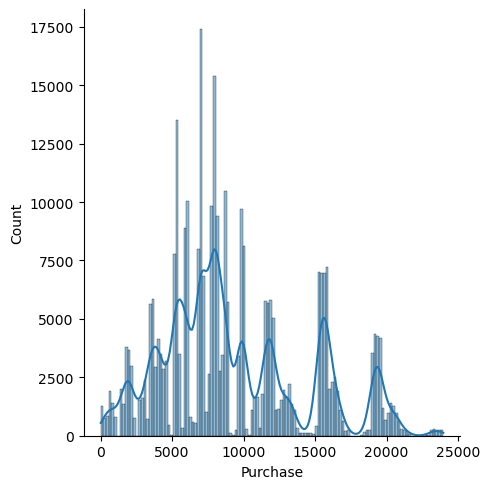

In [48]:
#Assuming 0 is unmarried and 1 is married
sns.displot(df[df['Marital_Status'] == 0]['Purchase'], kde=True)
plt.show()

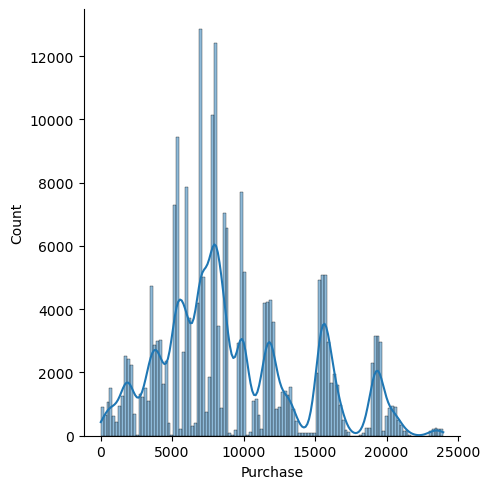

In [49]:
sns.displot(df[df['Marital_Status'] == 1]['Purchase'], kde=True)
plt.show()

In [50]:
print('Population Mean of for Unmarried Purchase: ',df[df['Marital_Status'] == 0]['Purchase'].mean())
print('Population Mean of for Married Purchase: ',df[df['Marital_Status'] == 1]['Purchase'].mean())

Population Mean of for Unmarried Purchase:  9265.907618921507
Population Mean of for Married Purchase:  9261.174574082374


In [51]:
unmarried_sample_means=[df[df['Marital_Status']== 0]['Purchase'].sample(300).mean() for i in range(1000)]
married_sample_means=[df[df['Marital_Status']== 1]['Purchase'].sample(300).mean() for i in range(1000)]

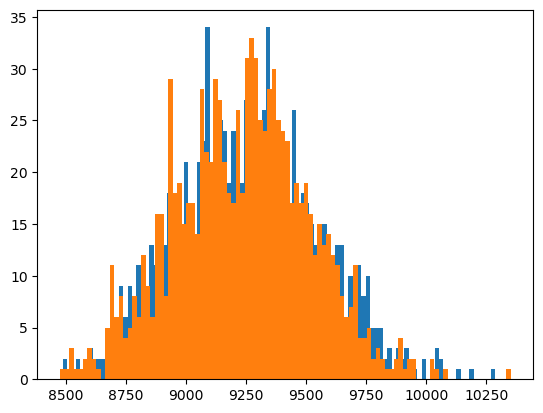

In [52]:
plt.hist(unmarried_sample_means, bins=100)
plt.hist(married_sample_means, bins= 100)
plt.show()

In [53]:
#Confidence intervals for unmarried and married

In [54]:
print(f"unmarried sample mean: {np.mean(unmarried_sample_means)} and standard deviation: {np.std(unmarried_sample_means)}")
print(f"married sample mean: {np.mean(married_sample_means)} and standard deviation: {np.std(married_sample_means)}")

unmarried sample mean: 9262.739413333333 and standard deviation: 291.3669336825422
married sample mean: 9234.75747 and standard deviation: 281.6397122329425


In [55]:
#Z score if the confidence interval is 95% and it is a one sided tale test

In [56]:
Lower_limit_unmarried = np.mean(unmarried_sample_means)- (np.std(unmarried_sample_means)/np.sqrt(1000))
Upper_limit_unmarried = np.mean(unmarried_sample_means)+ (np.std(unmarried_sample_means)/np.sqrt(1000))

print(f'Lower Limit Unmarried: {Lower_limit_unmarried} and Upper Limit unmarried: {Upper_limit_unmarried}')

Lower Limit Unmarried: 9253.525581880373 and Upper Limit unmarried: 9271.953244786293


In [57]:
Lower_limit_married = np.mean(married_sample_means)- (np.std(married_sample_means)/np.sqrt(1000))
Upper_limit_married = np.mean(married_sample_means)+ (np.std(married_sample_means)/np.sqrt(1000))

print(f'Lower Limit married: {Lower_limit_married} and Upper Limit married: {Upper_limit_married}')

Lower Limit married: 9225.851240297896 and Upper Limit married: 9243.663699702105


In [58]:
# Get the corresponding values of 2.5th and 97.5th percentiles
conf_interval = np.percentile(unmarried_sample_means,[2.5,97.5])
# Print the interval
print("The confidence interval: ",conf_interval)

The confidence interval:  [8727.94183333 9824.68383333]


In [59]:
# Get the corresponding values of 2.5th and 97.5th percentiles
conf_interval = np.percentile(married_sample_means,[2.5,97.5])
# Print the interval
print("The confidence interval: ",conf_interval)

The confidence interval:  [8694.9395     9761.77258333]


In [60]:
#Analysis for Age Group

In [61]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase,Age_label
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370,Teenager
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200,Teenager
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422,Teenager
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057,Teenager
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969,Senior


In [62]:
df['Age_label'].unique()

array(['Teenager', 'Senior', 'Early 30s', 'Middle Age', 'Early 20s'],
      dtype=object)

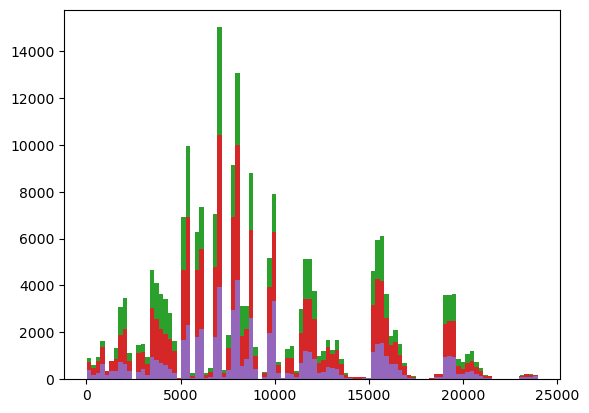

In [63]:
plt.hist(df[df['Age_label'] == 'Teenager']['Purchase'],bins=100)
plt.hist(df[df['Age_label'] == 'Early 20s']['Purchase'],bins=100)
plt.hist(df[df['Age_label'] == 'Early 30s']['Purchase'],bins=100)
plt.hist(df[df['Age_label'] == 'Middle Age']['Purchase'],bins=100)
plt.hist(df[df['Age_label'] == 'Senior']['Purchase'],bins=100)
plt.show()

In [64]:
print('Population Mean of for Teenagers Purchase: ',df[df['Age_label'] == 'Teenager']['Purchase'].mean())
print('Population Mean of for Early 20s Purchase: ',df[df['Age_label'] == 'Early 20s']['Purchase'].mean())
print('Population Mean of for Early 30s Purchase: ',df[df['Age_label'] == 'Early 30s']['Purchase'].mean())
print('Population Mean of for Middle Age Purchase: ',df[df['Age_label'] == 'Middle Age']['Purchase'].mean())
print('Population Mean of for Senior Purchase: ',df[df['Age_label'] == 'Senior']['Purchase'].mean())

Population Mean of for Teenagers Purchase:  8933.464640444974
Population Mean of for Early 20s Purchase:  9169.663606261289
Population Mean of for Early 30s Purchase:  9252.690632869888
Population Mean of for Middle Age Purchase:  9295.331742810537
Population Mean of for Senior Purchase:  9463.661678193484


In [65]:
teenagers_sample_means = [df[df['Age_label'] == 'Teenager']['Purchase'].sample(300).mean() for i in range(1000)]
early20s_sample_means = [df[df['Age_label'] == 'Early 20s']['Purchase'].sample(300).mean() for i in range(1000)]
early30s_sample_means = [df[df['Age_label'] == 'Early 30s']['Purchase'].sample(300).mean() for i in range(1000)]
middleage_sample_means = [df[df['Age_label'] == 'Middle Age']['Purchase'].sample(300).mean() for i in range(1000)]
senior_sample_means = [df[df['Age_label'] == 'Senior']['Purchase'].sample(300).mean() for i in range(1000)]

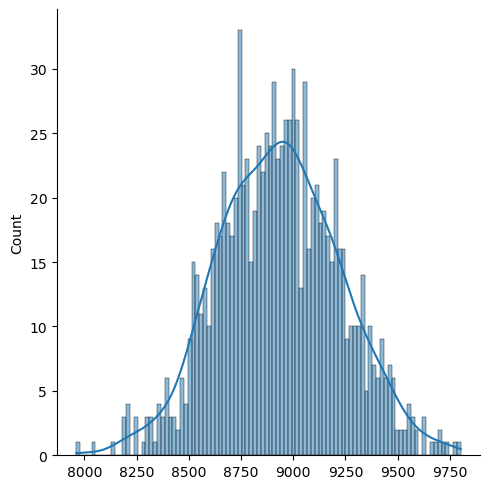

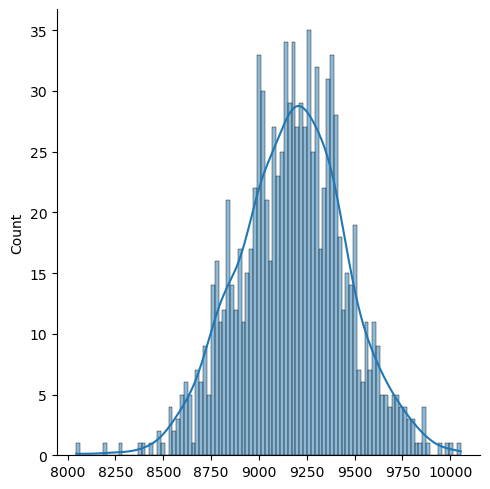

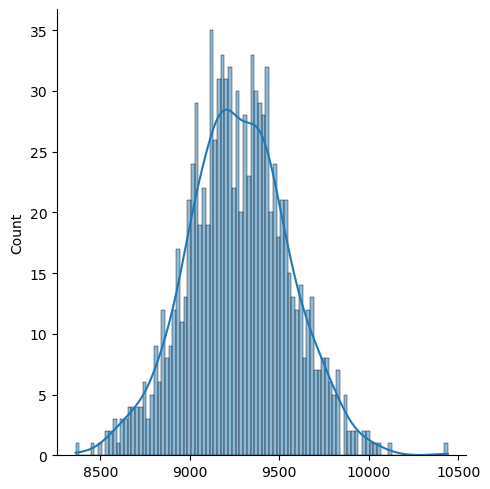

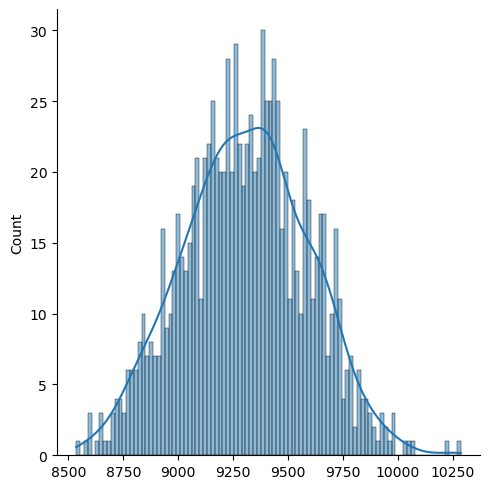

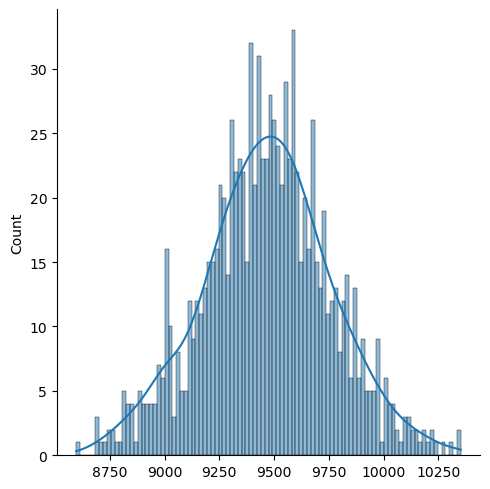

In [66]:
sns.displot(teenagers_sample_means, bins=100,kde=True,)
sns.displot(early20s_sample_means, bins= 100, kde=True)
sns.displot(early30s_sample_means, bins= 100, kde=True)
sns.displot(middleage_sample_means, bins= 100, kde=True)
sns.displot(senior_sample_means, bins= 100, kde=True)
plt.show()

In [67]:
#Confidence intervals for Age Group

In [68]:
print(f"Teenagers sample mean: {np.mean(teenagers_sample_means)} and standard deviation: {np.std(teenagers_sample_means)}")
print(f"Early 20s sample mean: {np.mean(early20s_sample_means)} and standard deviation: {np.std(early20s_sample_means)}")
print(f"Early 30s sample mean: {np.mean(early30s_sample_means)} and standard deviation: {np.std(early30s_sample_means)}")
print(f"Middle age sample mean: {np.mean(middleage_sample_means)} and standard deviation: {np.std(middleage_sample_means)}")
print(f"Senior sample mean: {np.mean(senior_sample_means)} and standard deviation: {np.std(senior_sample_means)}")

Teenagers sample mean: 8932.381896666666 and standard deviation: 291.0044165374898
Early 20s sample mean: 9173.30398 and standard deviation: 281.2514511324611
Early 30s sample mean: 9269.911496666668 and standard deviation: 282.9392792436686
Middle age sample mean: 9306.691670000002 and standard deviation: 283.01539022518034
Senior sample mean: 9467.61761 and standard deviation: 292.7126249901639


In [69]:
#Z score if the confidence interval is 95% and it is a one sided tale test

In [70]:
Lower_limit = np.mean(teenagers_sample_means)- (np.std(teenagers_sample_means)/np.sqrt(1000))
Upper_limit = np.mean(teenagers_sample_means)+ (np.std(teenagers_sample_means)/np.sqrt(1000))
print(f'Lower Limit teenagers: {Lower_limit} and Upper Limit teenagers: {Upper_limit}')

Lower_limit = np.mean(early20s_sample_means)- (np.std(early20s_sample_means)/np.sqrt(1000))
Upper_limit = np.mean(early20s_sample_means)+ (np.std(early20s_sample_means)/np.sqrt(1000))
print(f'Lower Limit early20s: {Lower_limit} and Upper Limit early20s: {Upper_limit}')

Lower_limit = np.mean(early30s_sample_means)- (np.std(early30s_sample_means)/np.sqrt(1000))
Upper_limit = np.mean(early30s_sample_means)+ (np.std(early30s_sample_means)/np.sqrt(1000))
print(f'Lower Limit early30s: {Lower_limit} and Upper Limit early30s: {Upper_limit}')

Lower_limit = np.mean(middleage_sample_means)- (np.std(middleage_sample_means)/np.sqrt(1000))
Upper_limit = np.mean(middleage_sample_means)+ (np.std(middleage_sample_means)/np.sqrt(1000))
print(f'Lower Limit middleage: {Lower_limit} and Upper Limit middleage: {Upper_limit}')

Lower_limit = np.mean(senior_sample_means)- (np.std(senior_sample_means)/np.sqrt(1000))
Upper_limit = np.mean(senior_sample_means)+ (np.std(senior_sample_means)/np.sqrt(1000))
print(f'Lower Limit senior: {Lower_limit} and Upper Limit senior: {Upper_limit}')

Lower Limit teenagers: 8923.179529012397 and Upper Limit teenagers: 8941.584264320934
Lower Limit early20s: 9164.41002819194 and Upper Limit early20s: 9182.197931808061
Lower Limit early30s: 9260.964171047304 and Upper Limit early30s: 9278.85882228603
Lower Limit middleage: 9297.741937540073 and Upper Limit middleage: 9315.64140245993
Lower Limit senior: 9458.361224051443 and Upper Limit senior: 9476.873995948556


In [71]:
# Get the corresponding values of 2.5th and 97.5th percentiles
conf_interval = np.percentile(teenagers_sample_means,[2.5,97.5])
print("The confidence interval: ",conf_interval)

conf_interval = np.percentile(early20s_sample_means,[2.5,97.5])
print("The confidence interval: ",conf_interval)

conf_interval = np.percentile(early30s_sample_means,[2.5,97.5])
print("The confidence interval: ",conf_interval)

conf_interval = np.percentile(middleage_sample_means,[2.5,97.5])
print("The confidence interval: ",conf_interval)

conf_interval = np.percentile(senior_sample_means,[2.5,97.5])
print("The confidence interval: ",conf_interval)

The confidence interval:  [8369.7275     9492.96116667]
The confidence interval:  [8612.07808333 9731.14791667]
The confidence interval:  [8699.8715     9821.01541667]
The confidence interval:  [8765.9295     9839.24358333]
The confidence interval:  [ 8869.48383333 10048.91691667]


In [72]:
#Overall Analysis

In [73]:
df['Age_label'].value_counts()

Age_label
Early 30s     219587
Middle Age    155714
Early 20s      99660
Senior         60005
Teenager       15102
Name: count, dtype: int64

In [74]:
df['Marital_Status'].value_counts()

Marital_Status
0    324731
1    225337
Name: count, dtype: int64

In [75]:
df['Product_Category'].value_counts()

Product_Category
5     150933
1     140378
8     113925
11     24287
2      23864
6      20466
3      20213
4      11753
16      9828
15      6290
13      5549
10      5125
12      3947
7       3721
18      3125
20      2550
19      1603
14      1523
17       578
9        410
Name: count, dtype: int64

In [76]:
df['City_Category'].value_counts()

City_Category
B    231173
C    171175
A    147720
Name: count, dtype: int64

In [77]:
df['Occupation'].value_counts()

Occupation
4     72308
0     69638
7     59133
1     47426
17    40043
20    33562
12    31179
14    27309
2     26588
16    25371
6     20355
3     17650
10    12930
5     12177
15    12165
11    11586
19     8461
13     7728
18     6622
9      6291
8      1546
Name: count, dtype: int64